--- Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 4108 entries, 0 to 4107
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   YEAR         4108 non-null   int64         
 1   DOY          4108 non-null   int64         
 2   T2M          4108 non-null   float64       
 3   T2M_MAX      4108 non-null   float64       
 4   T2M_MIN      4108 non-null   float64       
 5   T2M_RANGE    4108 non-null   float64       
 6   PRECTOTCORR  4108 non-null   float64       
 7   RH2M         4108 non-null   float64       
 8   WS2M         4108 non-null   float64       
 9   WS2M_MAX     4108 non-null   float64       
 10  PS           4108 non-null   float64       
 11  QV2M         4108 non-null   float64       
 12  Country      4108 non-null   str           
 13  Date         4108 non-null   datetime64[us]
 14  Month        4108 non-null   int32         
dtypes: datetime64[us](1), float64(10), int32(1), int

,Missing Values,Percentage (%)
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0



--- Summary Statistics ---


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046



--- Outliers Detected (|Z| > 3) ---
132


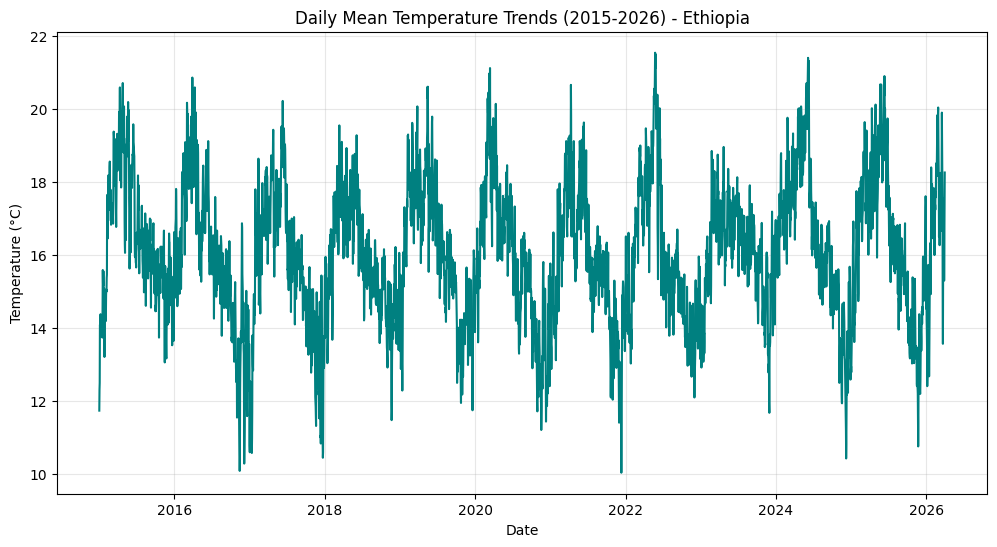


Success: Cleaned data saved as 'ethiopia_cleaned.csv'


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Load the dataset 
# Ensure your folder structure matches: notebooks/ethiopia_eda.ipynb and data/ethiopia.csv
df = pd.read_csv('../data/ethiopia.csv')

# 2. Feature Engineering & Metadata
df['Country'] = 'Ethiopia'
# Convert YEAR and DOY (Day of Year) into a standard Date format
df['Date'] = pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format='%Y%j')
df['Month'] = df['Date'].dt.month

# 3. Data Cleaning
# Replace NASA's -999 placeholder with NaN so it doesn't ruin your averages
df.replace(-999, np.nan, inplace=True)

# 4. Data Quality Check
print("--- Data Info ---")
print(df.info())

duplicates = df.duplicated().sum()
print(f"\nDuplicate rows found: {duplicates}")
if duplicates > 0:
    df.drop_duplicates(inplace=True)

# 5. Missing Value Report (The 5% Rule)
missing_report = pd.DataFrame({
    'Missing Values': df.isna().sum(),
    'Percentage (%)': (df.isna().sum() / len(df)) * 100
})
print("\n--- Missing Value Report ---")
display(missing_report)

# 6. Summary Statistics
print("\n--- Summary Statistics ---")
display(df.describe())

# 7. Outlier Detection (Z-Score Analysis)
# Flagging extreme weather events where |Z| > 3
cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M']
z_scores = np.abs(stats.zscore(df[cols_to_check], nan_policy='omit'))

# Count outliers per column
outliers_per_col = (z_scores > 3).sum()
print("\n--- Outliers Detected (|Z| > 3) ---")
print(outliers_per_col)

# 8. Visualizing Temperature Trends
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Date', y='T2M', color='teal')
plt.title('Daily Mean Temperature Trends (2015-2026) - Ethiopia')
plt.ylabel('Temperature (°C)')
plt.grid(True, alpha=0.3)
plt.show()

# 9. Save Cleaned Data for Task 3
df.to_csv('../data/ethiopia_cleaned.csv', index=False)
print("\nSuccess: Cleaned data saved as 'ethiopia_cleaned.csv'")